<a href="https://colab.research.google.com/github/put-star/Flask_Blog1/blob/master/Signal%20processing%20ECG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install neurokit2 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 12.1 MB/s eta 0:00:00


In [ ]:
import os

folder_path = '/content/drive/MyDrive/archieve'

# Tampilkan semua file di folder
for file in os.listdir(folder_path):
    print(file)

16265_annotations.csv
16265_ekg.csv
16272_annotations.csv
16265_metadata.json
16273_annotations.csv
16272_metadata.json
16272_ekg.csv
16273_metadata.json
16420_annotations.csv
16273_ekg.csv
16483_annotations.csv
16420_ekg.csv
16420_metadata.json
16483_ekg.csv
16483_metadata.json
16539_annotations.csv
16539_ekg.csv
16539_metadata.json
16773_annotations.csv
16786_annotations.csv
16773_metadata.json
16773_ekg.csv
16786_metadata.json
16786_ekg.csv
16795_annotations.csv
16795_ekg.csv
16795_metadata.json
17052_annotations.csv
17052_metadata.json
17052_ekg.csv
17453_annotations.csv
17453_ekg.csv
17453_metadata.json
18177_annotations.csv
18177_metadata.json
18177_ekg.csv
18184_annotations.csv
18184_metadata.json
18184_ekg.csv
19088_annotations.csv
19088_metadata.json
19088_ekg.csv
19090_annotations.csv
19093_annotations.csv
19090_metadata.json
19090_ekg.csv
19093_ekg.csv
19140_annotations.csv
19093_metadata.json
19140_ekg.csv
19140_metadata.json
19830_annotations.csv
19830_metadata.json
annota

In [ ]:
import neurokit2 # easy EKG processing
import pandas as pd # open CSV files
import matplotlib.pyplot as plt # graphing

In [ ]:
# We won't actually use the Neurokit default data in this notebook, but it exists if you need it.
neurokit2.data()

,ECG,EDA,Photosensor,RSP
0,-0.015869,13.196868,5.0,0.778931
1,-0.011703,13.197173,5.0,0.777588
2,-0.009766,13.197020,5.0,0.777435
3,-0.013321,13.197631,5.0,0.777557
4,-0.009583,13.196715,5.0,0.775299
...,...,...,...,...
14995,-0.007675,14.873656,5.0,1.351868
14996,-0.005203,14.873961,5.0,1.356689
14997,-0.004272,14.874266,5.0,1.361938
14998,-0.000458,14.875335,5.0,1.366821


In [ ]:
# Open the EKG file with Pandas
filepath = "/content/drive/MyDrive/archieve/16272_ekg.csv"
ekg = pd.read_csv(filepath)

/tmp/ipykernel_4121/4161197149.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  ekg = pd.read_csv(filepath)


In [ ]:
# Show the EKG dataframe. There are 11,520,000 rows. That's 25 hours of heart data.
ekg

,Unnamed: 0,timestamp,voltage_channel_1_mv,voltage_channel_2_mv,annotation_symbol,channel,aux_note,num
0,0,0 days 00:00:00,-0.185,-0.085,NaN,NaN,NaN,NaN
1,1,0 days 00:00:00.007812500,-0.215,-0.105,|,0.0,NaN,11.0
2,2,0 days 00:00:00.015625,-0.215,-0.105,NaN,NaN,NaN,NaN
3,3,0 days 00:00:00.023437500,-0.245,-0.105,NaN,NaN,NaN,NaN
4,4,0 days 00:00:00.031250,-0.205,-0.095,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
11519995,11519995,1 days 00:59:59.960937500,-0.040,-0.075,NaN,NaN,NaN,NaN
11519996,11519996,1 days 00:59:59.968750,-0.040,-0.075,NaN,NaN,NaN,NaN
11519997,11519997,1 days 00:59:59.976562500,-0.040,-0.075,NaN,NaN,NaN,NaN
11519998,11519998,1 days 00:59:59.984375,-0.040,-0.075,NaN,NaN,NaN,NaN


In [ ]:
# Grab and print out the column for channel 1. These are real voltages from the heart in millivolts.
channel1 = ekg["voltage_channel_1_mv"]

channel1

,voltage_channel_1_mv
0,-0.185
1,-0.215
2,-0.215
3,-0.245
4,-0.205
...,...
11519995,-0.040
11519996,-0.040
11519997,-0.040
11519998,-0.040


In [ ]:
# Get just the first 750 data points from the dataframe.
# In reality, this gets items 0 to 749, since indices in programming languages start at 0.
# The actual number doesn't matter. We picked 750 to get a reasonable number of heartbeats.
channel1_reduced = channel1[0:750]

In [ ]:
# Show the new 750-item array of data
channel1_reduced

,voltage_channel_1_mv
0,-0.185
1,-0.215
2,-0.215
3,-0.245
4,-0.205
...,...
745,-0.035
746,-0.015
747,-0.005
748,0.005


Text(0.5, 1.0, 'First Six Heartbeats of the EKG')

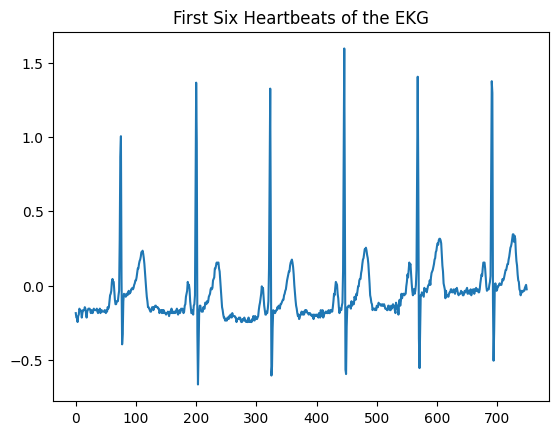

In [ ]:
# Graph the new, shortened array of EKG data
plt.plot(channel1_reduced)
plt.title('First Six Heartbeats of the EKG')

 Process and the EKG with Neurokit's ecg_process() function
This is the first of a few methods that we'll use to label EKGs. The ecg_process() function both smooths the EKG and finds the locations of the PQRST waves for each heartbeat. We can take this information and combine it into a graph, so that you can see real EKG waves labeled with their respective names.

We're going to give the smaller subset of the EKG that has only 750 data points (channel1_reduced) to the ecg_process() function, so that it doesn't take too long. Processing theh whole 24-hour EKG would take forever.

To run the function, all we need is our EKG data and its sampling rate (samples per second, or Hertz). The sampling rate can be found in each EKG's *_metadata.json file. All EKGs in this dataset should have a sampling rate of 128 Hz.

The ecg_process() function actually has a few dozen modes to choose from, based on algorithms from different EKG analysis research publications that have been published over the years. We'll use the default neurokit mode in this notebook (which we don't have to give as an argument to the function since it is the default), but know that you have many options to choose from. If you look at the actual Neurokit code on Github, you can see that the _ecg_findpeaks_findmethod() function that helps ecg_process() do its job has a list of about 20 methods to choose from.

In [ ]:
# Process the EKG. This will both smooth and identify the P, Q, R, S, and T waves.
# The data was collected at 128 samples per second (or "Hertz").
processed_ekg = neurokit2.ecg_process(channel1_reduced, sampling_rate=128)

In [ ]:
# Show the entire result that Neurokit gave back.
# It returns two things:
# 1. a Pandas DataFrame with the original and smoothed EKGs
# 2. a dictionary of all of the peaks/waves it found (P, Q, R, S, and T waves)
#
# The DataFrame also has the peaks, as well as some extra columns, but ignore those for now.

processed_ekg

(     ECG_Raw  ECG_Clean   ECG_Rate  ECG_Quality  ECG_R_Peaks  ECG_P_Peaks  \
 0     -0.185  -0.043786  62.236629     0.713576            0            0   
 1     -0.215  -0.067089  62.236629     0.713576            0            0   
 2     -0.215  -0.082898  62.236629     0.713576            0            0   
 3     -0.245  -0.088714  62.236629     0.713576            0            0   
 4     -0.205  -0.074539  62.236629     0.713576            0            0   
 ..       ...        ...        ...          ...          ...          ...   
 745   -0.035  -0.079815  62.439024     0.000000            0            0   
 746   -0.015  -0.058465  62.439024     0.000000            0            0   
 747   -0.005  -0.036646  62.439024     0.000000            0            0   
 748    0.005  -0.026843  62.439024     0.000000            0            0   
 749   -0.025  -0.036670  62.439024     0.000000            0            0   
 
      ECG_P_Onsets  ECG_P_Offsets  ECG_Q_Peaks  ECG_R_Onsets  

In [ ]:
# Save the Pandas dataframe itself as its own variable
ekg_df = processed_ekg[0]
ekg_df

,ECG_Raw,ECG_Clean,ECG_Rate,ECG_Quality,ECG_R_Peaks,ECG_P_Peaks,ECG_P_Onsets,ECG_P_Offsets,ECG_Q_Peaks,ECG_R_Onsets,ECG_R_Offsets,ECG_S_Peaks,ECG_T_Peaks,ECG_T_Onsets,ECG_T_Offsets,ECG_Phase_Atrial,ECG_Phase_Completion_Atrial,ECG_Phase_Ventricular,ECG_Phase_Completion_Ventricular
0,-0.185,-0.043786,62.236629,0.713576,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1,-0.215,-0.067089,62.236629,0.713576,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
2,-0.215,-0.082898,62.236629,0.713576,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
3,-0.245,-0.088714,62.236629,0.713576,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
4,-0.205,-0.074539,62.236629,0.713576,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,-0.035,-0.079815,62.439024,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
746,-0.015,-0.058465,62.439024,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
747,-0.005,-0.036646,62.439024,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
748,0.005,-0.026843,62.439024,0.000000,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0


6. Graph the EKG after ecg_process() with Matplotlib
The ecg_process() function did two things: it smoothed the EKG and identified the PQRST waves. Let's graph the smoothed EKG and put markers where the waves were found.

The ECG_Clean column in the new dataframe holds the smoothed EKG data. We can graph it with one line of code thanks to how well Pandas and Matplotlib work together.

Since we pared down the EKG dataset to just the first 750 rows of data, the graphs below won't hold all 24-hours of heartbeats. They'll only show 6 heartbeats.

In [ ]:
# Show the smoothed/clean EKG voltages
ekg_df["ECG_Clean"]

,ECG_Clean
0,-0.043786
1,-0.067089
2,-0.082898
3,-0.088714
4,-0.074539
...,...
745,-0.079815
746,-0.058465
747,-0.036646
748,-0.026843


In [ ]:
# Show the indices of the waves that Neurokit found

# Get the dictionary of data from Neurokit that contains all of the waves it found
ekg_metadata = processed_ekg[1]

# Extract the indices of the waves from the metadata
p_waves = ekg_metadata['ECG_P_Peaks']
q_waves = ekg_metadata['ECG_Q_Peaks']
r_waves = ekg_metadata['ECG_R_Peaks']
s_waves = ekg_metadata['ECG_S_Peaks']
t_waves = ekg_metadata['ECG_T_Peaks']

# Print the indices of the waves, just so you can see what the data looks like.
print('Indices of the PQRST waves found by Neurokit:\n' + \
      f'P waves: {p_waves}\n' + \
      f'Q waves: {q_waves}\n' + \
      f'R waves: {r_waves}\n' + \
      f'S waves: {s_waves}\n' + \
      f'T waves: {t_waves}\n'
)

Indices of the PQRST waves found by Neurokit:
P waves: [61, 187, 310, 433, 555, 678]
Q waves: [np.int64(67), np.int64(193), np.int64(316), np.int64(438), np.int64(560), np.int64(685)]
R waves: [ 74 200 323 446 568 691]
S waves: [np.int64(78), np.int64(203), np.int64(326), np.int64(449), np.int64(571), np.int64(694)]
T waves: [110, 235, 358, 481, 605, 727]



Text(0.5, 1.0, 'First Six Heartbeats from EKG (Smoothed)')

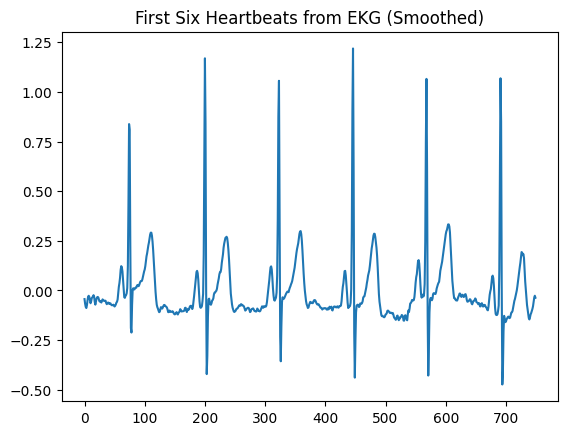

In [ ]:
# Graph the post-processed, smoothed EKG by itself (no wave labels)
ekg_df["ECG_Clean"].plot()
plt.title('First Six Heartbeats from EKG (Smoothed)')

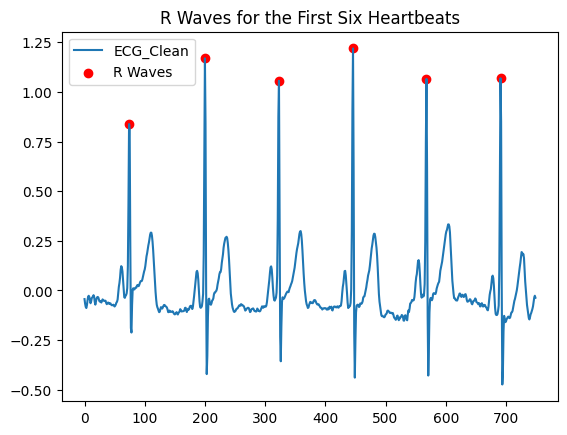

In [ ]:
# Graph the EKG with markers for the just the R waves to keep things simple.

# First, plot the EKG itself.
ekg_df["ECG_Clean"].plot()

# Add markers where Neurokit found R waves.
x = r_waves
y = ekg_df["ECG_Clean"][x]
plt.scatter(x, y, color='red', label='R Waves')

# Add a title
plt.title('R Waves for the First Six Heartbeats')

# Add a legend
plt.legend()

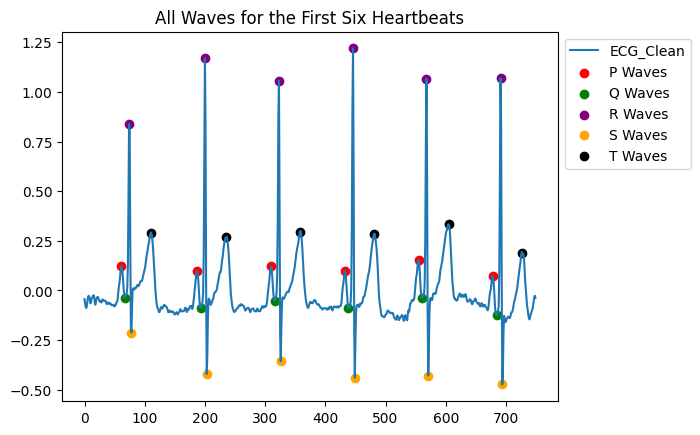

In [ ]:
# Graph the EKG with markers for all of the PQRST waves.

# First, plot the EKG itself.
ekg_df["ECG_Clean"].plot()

# Add markers where Neurokit found P waves
x = p_waves
y = ekg_df["ECG_Clean"][x]
plt.scatter(x, y, color='red', label='P Waves')

# Add markers where Neurokit found Q waves
x = q_waves
y = ekg_df["ECG_Clean"][x]
plt.scatter(x, y, color='green', label='Q Waves')

# Add markers where Neurokit found R waves
x = r_waves
y = ekg_df["ECG_Clean"][x]
plt.scatter(x, y, color='purple', label='R Waves')

# Add markers where Neurokit found S waves
x = s_waves
y = ekg_df["ECG_Clean"][x]
plt.scatter(x, y, color='orange', label='S Waves')

# Add markers where Neurokit found T waves
x = t_waves
y = ekg_df["ECG_Clean"][x]
plt.scatter(x, y, color='black', label='T Waves')

# Add a title
plt.title('All Waves for the First Six Heartbeats')

# Add a legend and move it to outside of the graph box
plt.legend(bbox_to_anchor=(1, 1))

(     ECG_P_Peaks  ECG_Q_Peaks  ECG_S_Peaks  ECG_T_Peaks  ECG_P_Onsets  \
 0              0            0            0            0             0   
 1              0            0            0            0             0   
 2              0            0            0            0             0   
 3              0            0            0            0             0   
 4              0            0            0            0             0   
 ..           ...          ...          ...          ...           ...   
 745            0            0            0            0             0   
 746            0            0            0            0             0   
 747            0            0            0            0             0   
 748            0            0            0            0             0   
 749            0            0            0            0             0   
 
      ECG_T_Offsets  
 0                0  
 1                0  
 2                0  
 3                0  


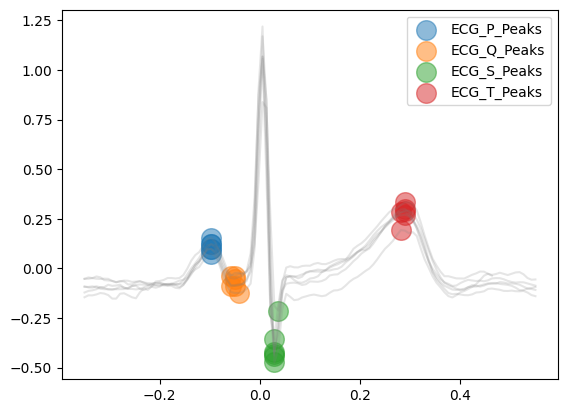

In [ ]:
# Get the column of smoothed EKG data
smoothed_ekg = ekg_df['ECG_Clean']

# Get the indices of the R waves that Neurokit already found
r_waves = processed_ekg[1]['ECG_R_Peaks']

# Find the waves and graph them
neurokit2.ecg_delineate(smoothed_ekg, rpeaks=r_waves, sampling_rate=128,
                        show=True, method='peaks')

Text(0.5, 1.0, 'First Heartbeats from the Original, Raw EKG')

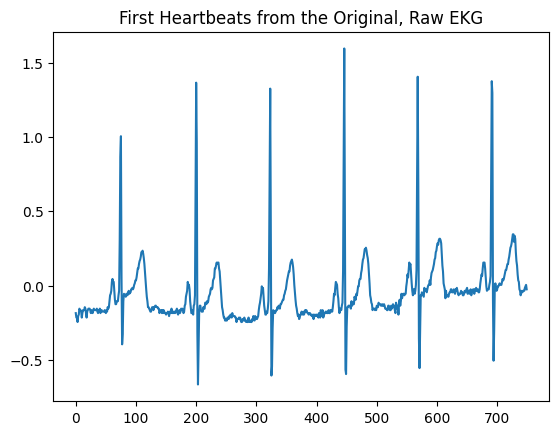

In [ ]:
ekg_df["ECG_Raw"].plot()
plt.title('First Heartbeats from the Original, Raw EKG')

Text(0.5, 1.0, 'First Two Heartbeats from the Original, Raw EKG')

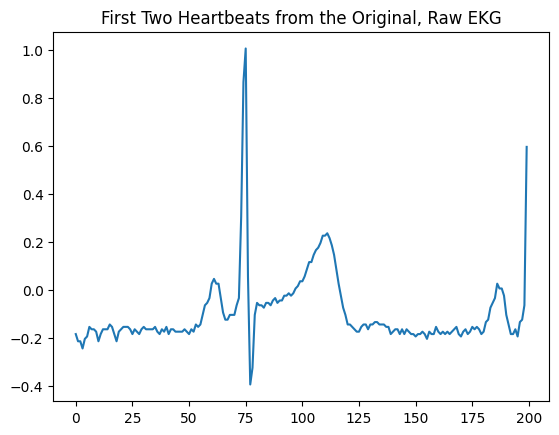

In [ ]:
# Zoom in on just the first two heartbeats (200 data points)
ekg_df["ECG_Raw"][0:200].plot()
plt.title('First Two Heartbeats from the Original, Raw EKG')

Text(0.5, 1.0, 'Smoothed EKG (Neurokit2)')

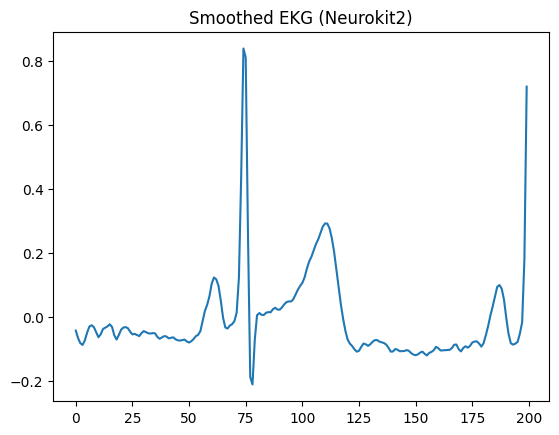

In [ ]:
# Plot two heartbeats from the smoothed EKG
ekg_df["ECG_Clean"][0:200].plot()
plt.title('Smoothed EKG (Neurokit2)')

In [ ]:
Butterworth Filter
The Butterworth filter is another filter that SciPy provides. However, unlike median and Savitzky-Golay filters, it is not based on a data point's neighbors. Instead, it only considers frequency. We can filter out just high frequencies, just low frequencies, frequencies in a range in the middle, and so on.

For the EKG, since we want to get of the jagged edges (or noise, which is high frequency), we will use a "low pass" Butterworth filter. That is, we will let low frequencies "pass through" to the end result.

The steps for a Butterworth filter are also different. We have to do two things:

Create a generic Butterworth filter with the butter() function
Give both the new Butterworth filter and our EKG data to the sosfilt() function.
The arguments that we'll give to the butter() function are:

filter order, or how steep we want the filter drop off to be (we'll choose 3)
critical frequency, or the cutoff frequency (we'll do 15 Hz)
type of filter (lowpass)
sample rate of the original EKG (128 Hz)
output format (sos or second-order sections, which allows us to use sosfilt() after that)
The butter() function allows us to ask for the output to be in ba or zpk format, which you can read more about on the function's documentation page. We give the argument output='sos' so that we can easily use the sosfilt() function on our EKG data to smooth it.

In [ ]:
import neurokit2 # easy EKG processing
import pandas as pd # open CSV files
import matplotlib.pyplot as plt # graphing
import scipy # general signal filtering and processing

In [ ]:


# Create the reusable Butterworth filter. Note that we do not give it our EKG data at all yet.
#
# We give the function 5 arguments:
# filter order = 3
# critical frequency = 15
# type of filter = lowpass
# sample rate = 128
# output = 'sos' or second-order sections
butter_filter = scipy.signal.butter(3, 15, "lowpass", fs=128, output='sos')

In [ ]:
# Save the raw EKG data as its own variable
raw_ekg = ekg_df["ECG_Raw"]

# Run the EKG through the Butterworth filter that we just created
filtered_ekg = scipy.signal.sosfilt(butter_filter, raw_ekg)

In [ ]:
# Look at the post-filter EKG voltages
filtered_ekg

array([-0.00499348, -0.02853688, -0.07756288, -0.13973208, -0.19512115,
       -0.22936197, -0.23713035, -0.22267757, -0.19740238, -0.17416483,
       -0.16205599, -0.16390522, -0.17417012, -0.18264103, -0.1836197 ,
       -0.1779443 , -0.16868195, -0.16012942, -0.1582688 , -0.16584564,
       -0.17729503, -0.18365942, -0.18118846, -0.17250139, -0.16285996,
       -0.15728665, -0.15814334, -0.16340025, -0.16948673, -0.17446648,
       -0.17652769, -0.17425517, -0.16924593, -0.16470999, -0.16239043,
       -0.16190101, -0.16216546, -0.16362849, -0.16715019, -0.17122952,
       -0.17332313, -0.1727757 , -0.17129412, -0.17026651, -0.1694758 ,
       -0.16920776, -0.17015685, -0.17199121, -0.17357167, -0.17388076,
       -0.1734718 , -0.17368926, -0.17422958, -0.1734137 , -0.16977104,
       -0.16342174, -0.15509679, -0.14278908, -0.12349549, -0.09820833,
       -0.07018628, -0.04014641, -0.0091671 ,  0.01701952,  0.03096165,
        0.02652066,  0.00108154, -0.0398588 , -0.08275347, -0.11

Text(0.5, 1.0, 'First Two Heartbeats after Butterworth Filter')

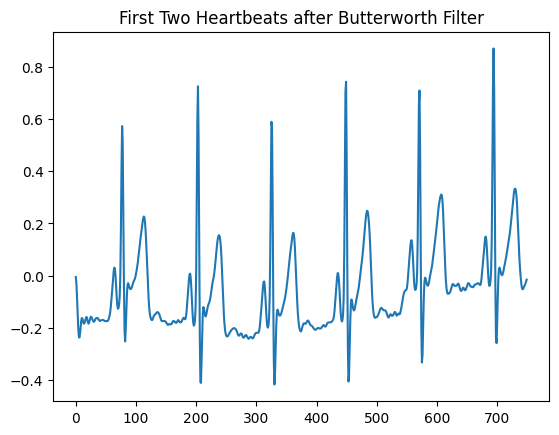

In [ ]:
# Graph the first two heartbeats from the EKG post-Butterworth filter
plt.plot(filtered_ekg)
plt.title('First Two Heartbeats after Butterworth Filter')

In [ ]:
# Cek dari metadata atau tebak dari panjang sinyal
print("Panjang sinyal:", len(filtered_ekg), "sample")

# Jika data 2 heartbeat dan HR normal ~70 bpm:
# durasi ≈ 2 * (60/70) ≈ 1.7 detik
# sampling_rate ≈ len(filtered_ekg) / 1.7

Panjang sinyal: 750 sample


Jumlah R-peak terdeteksi : 2
RR intervals (ms)        : [654.7]
Heart Rate per beat      : [91.6] bpm
Heart Rate rata-rata     : 91.6 bpm


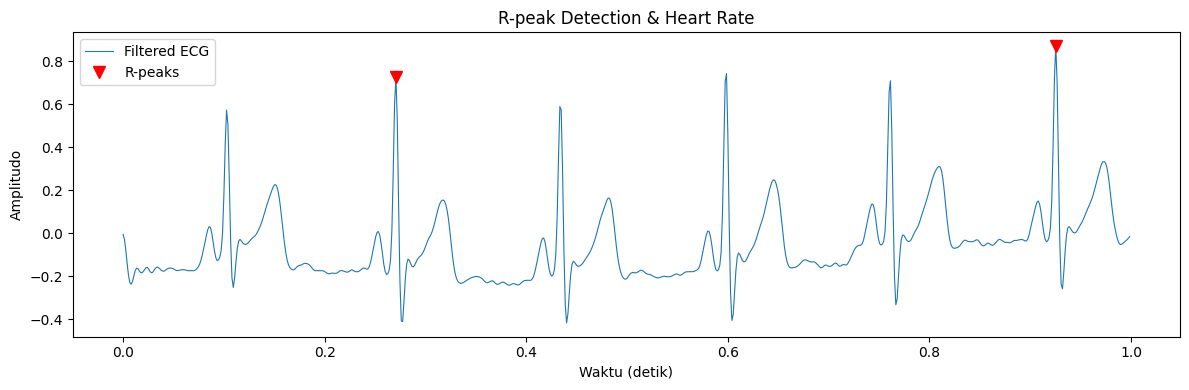

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Asumsikan sampling_rate diketahui (misal 360 Hz untuk MIT-BIH)
sampling_rate = 750  # Hz — sesuaikan dengan data Anda

# 1. Deteksi R-peak dari sinyal yang sudah difilter
peaks, properties = find_peaks(
    filtered_ekg,
    height=np.mean(filtered_ekg) + 0.8 * np.std(filtered_ekg),  # threshold otomatis
    distance=sampling_rate * 0.4   # minimal jarak antar-peak (0.4 detik = 150 bpm max)
)

# 2. Hitung RR interval (dalam detik)
rr_intervals_samples = np.diff(peaks)               # selisih dalam satuan sample
rr_intervals_ms = (rr_intervals_samples / sampling_rate) * 1000  # konversi ke ms

# 3. Hitung Heart Rate
hr_per_beat = 60000 / rr_intervals_ms              # HR per beat (bpm)
hr_mean = np.mean(hr_per_beat)                     # HR rata-rata

print(f"Jumlah R-peak terdeteksi : {len(peaks)}")
print(f"RR intervals (ms)        : {np.round(rr_intervals_ms, 1)}")
print(f"Heart Rate per beat      : {np.round(hr_per_beat, 1)} bpm")
print(f"Heart Rate rata-rata     : {hr_mean:.1f} bpm")

# 4. Visualisasi
time_axis = np.arange(len(filtered_ekg)) / sampling_rate  # sumbu waktu (detik)

plt.figure(figsize=(12, 4))
plt.plot(time_axis, filtered_ekg, label='Filtered ECG', linewidth=0.8)
plt.plot(time_axis[peaks], filtered_ekg[peaks], 'rv', markersize=8, label='R-peaks')
plt.title('R-peak Detection & Heart Rate')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.legend()
plt.tight_layout()
plt.show()